In [25]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten, Dense, Input, BatchNormalization, Dropout
import matplotlib.pyplot as plt
import numpy as np

In [26]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [27]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [28]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [29]:
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

In [30]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Pixel values now between 0 and 1: min={X_train.min():.2f}, max={X_train.max():.2f}")

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
Pixel values now between 0 and 1: min=0.00, max=1.00


In [ ]:
from tensorflow.keras.regularizers import l2


In [40]:
model = Sequential()
model.add(Input(shape=(28, 28, 1)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu', kernel_regularizer= l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [41]:

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,058 (976.79 KB)

 Trainable params: 249,610 (975.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [42]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=0.001
)

In [43]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [44]:
history = model.fit(X_train, y_train, epochs = 10 , validation_split = 0.2, batch_size = 64, verbose = 1)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7872 - loss: 0.7954 - val_accuracy: 0.8695 - val_loss: 0.5231
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8661 - loss: 0.5127 - val_accuracy: 0.8849 - val_loss: 0.4403
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8861 - loss: 0.4226 - val_accuracy: 0.9072 - val_loss: 0.3551
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8937 - loss: 0.3847 - val_accuracy: 0.9071 - val_loss: 0.3464
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9024 - loss: 0.3560 - val_accuracy: 0.9057 - val_loss: 0.3406
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9080 - loss: 0.3397 - val_accuracy: 0.9092 - val_loss: 0.3305
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9119 - loss: 0.3292 - val_accuracy: 0.8975 - val_loss: 0.3599
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9158 - loss: 0.3181 - val_accuracy: 0

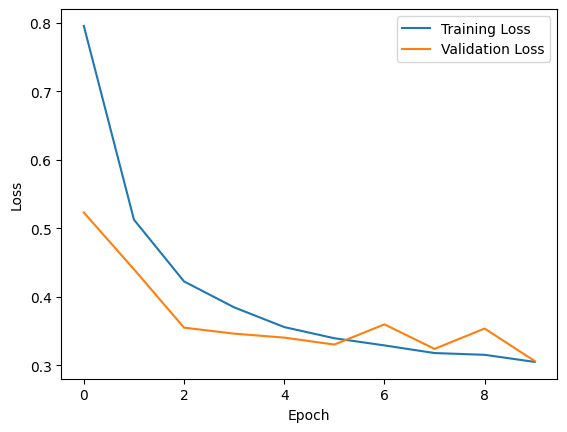

In [45]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

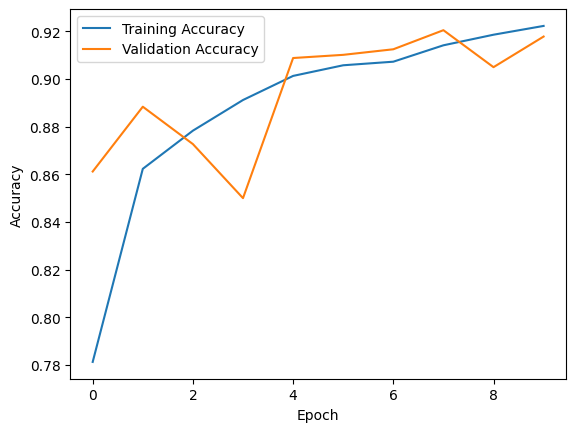

In [38]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Evaluate on training data
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f"✅ Training Accuracy: {train_accuracy:.4f} ({train_accuracy:.2%})")
print(f"✅ Training Loss: {train_loss:.4f}")
# ============================================
# 1. TEST SET EVALUATION
# ============================================
print("="*60)
print("TEST SET EVALUATION")
print("="*60)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")

y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)


from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n📊 Additional Metrics:")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall: {recall:.4f}")
print(f"  - F1-Score: {f1:.4f}")

✅ Training Accuracy: 0.9369 (93.69%)
✅ Training Loss: 0.2602
TEST SET EVALUATION
✅ Test Loss: 0.3219
✅ Test Accuracy: 0.9160 (91.60%)

📊 Additional Metrics:
  - Precision: 0.9197
  - Recall: 0.9160
  - F1-Score: 0.9166


🔍 PREDICTION RESULT
True Label:    Dress
Predicted:     Dress
Confidence:    99.60%
✅ Correct!


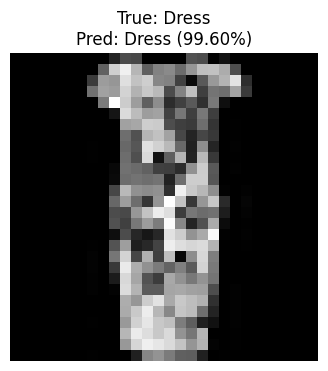

(np.int64(3), np.float32(0.9959538))

In [48]:
from tensorflow.keras.preprocessing import image

# ============================================
# 1. PREDICT SINGLE IMAGE (From Test Set)
# ============================================

def predict_single_image(model, X_test, y_test, class_names, index):
    """
    Predict and display a single image from test set
    """
    # Get image and true label
    img = X_test[index]
    true_label = y_test[index]

    # Reshape for prediction
    img_input = img.reshape(1, 28, 28, 1)

    # Make prediction
    pred_proba = model.predict(img_input, verbose=0)
    pred_label = np.argmax(pred_proba)
    confidence = np.max(pred_proba)

    # Display results
    print("="*50)
    print(f"🔍 PREDICTION RESULT")
    print("="*50)
    print(f"True Label:    {class_names[true_label]}")
    print(f"Predicted:     {class_names[pred_label]}")
    print(f"Confidence:    {confidence:.2%}")
    print(f"✅ Correct!" if pred_label == true_label else "❌ Incorrect!")

    # Show image
    plt.figure(figsize=(4, 4))
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2%})")
    plt.axis('off')
    plt.show()

    return pred_label, confidence

# Test with a random image from test set
predict_single_image(model, X_test, y_test, class_names, index=100)

📤 Please upload an image (28x28 or any size)...


Saving pant.avif to pant.avif

🔍 Processing: pant.avif

📊 Prediction Probabilities:
----------------------------------------
T-shirt/top    : 3.33% █
Trouser        : 44.63% ██████████████████████
Pullover       : 1.29% 
Dress          : 1.94% 
Coat           : 3.25% █
Sandal         : 0.02% 
Shirt          : 12.51% ██████
Sneaker        : 0.04% 
Bag            : 32.05% ████████████████
Ankle boot     : 0.93% 

✅ PREDICTION: Trouser
📊 Confidence: 44.63%


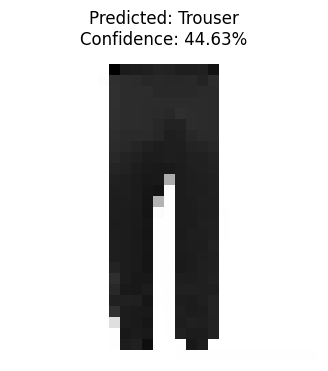

('Trouser', np.float32(0.44630373))

In [ ]:
# ============================================
# 2. UPLOAD AND PREDICT
# ============================================

def upload_and_predict(model, class_names, uploaded_files):
    """
    Process uploaded image files and return predictions
    """
    for filename, file_bytes in uploaded_files.items():
        print(f"\n🔍 Processing: {filename}")
        img = image.load_img(file_bytes, target_size=(28, 28), color_mode='grayscale')
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0
        img_array = img_array.reshape(1, 28, 28, 1)

        pred_proba = model.predict(img_array, verbose=0)
        pred_label = np.argmax(pred_proba)
        confidence = np.max(pred_proba)

        print("\n📊 Prediction Probabilities:")
        print("-"*40)
        for i, name in enumerate(class_names):
            prob = pred_proba[0][i]
            bar = "█" * int(prob * 50)
            print(f"{name:15s}: {prob:.2%} {bar}")

        print("\n" + "="*50)
        print(f"✅ PREDICTION: {class_names[pred_label]}")
        print(f"📊 Confidence: {confidence:.2%}")
        print("="*50)

        plt.figure(figsize=(4, 4))
        plt.imshow(img, cmap='gray')
        plt.title(f"Predicted: {class_names[pred_label]}\nConfidence: {confidence:.2%}")
        plt.axis('off')
        plt.show()

        return class_names[pred_label], confidence

# Example usage: pass a dict of filename -> file-like object
# uploaded_files = {'image.png': open('image.png', 'rb')}
# upload_and_predict(model, class_names, uploaded_files)


🔍 TOP 3 PREDICTIONS
1. Shirt: 52.59%
2. T-shirt/top: 22.57%
3. Dress: 11.60%


/tmp/ipykernel_1075/295661162.py:49: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray((img_array.reshape(28, 28) * 255).astype('uint8'), mode='L').save(temp_path)


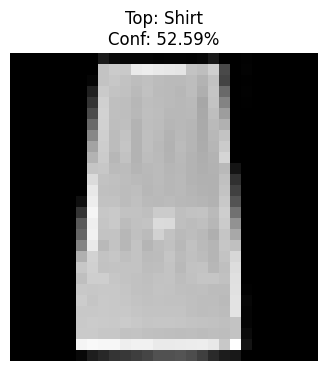


✅ Final Prediction: Shirt (52.59%)
✅ True Label: Dress
❌ Incorrect!


In [55]:
# ============================================
# 3. PREDICT WITH TOP 3 CLASSES (FIXED)
# ============================================

def predict_top3(model, image_path, class_names):
    """
    Predict and show top 3 most likely classes
    """
    # Load and preprocess
    img = image.load_img(image_path, target_size=(28, 28), color_mode='grayscale')
    img_array = image.img_to_array(img) / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)

    # Predict
    pred_proba = model.predict(img_array, verbose=0)[0]

    # Get top 3
    top3_indices = np.argsort(pred_proba)[-3:][::-1]
    top3_probs = pred_proba[top3_indices]

    # Print results
    print("\n" + "="*50)
    print("🔍 TOP 3 PREDICTIONS")
    print("="*50)
    for i, (idx, prob) in enumerate(zip(top3_indices, top3_probs), 1):
        print(f"{i}. {class_names[idx]}: {prob:.2%}")
    print("="*50)

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"Top: {class_names[top3_indices[0]]}\nConf: {top3_probs[0]:.2%}")
    plt.axis('off')
    plt.show()

    return top3_indices[0], top3_probs[0]

# ============================================
# TEST THE FUNCTION
# ============================================

# Test on a random image from test set
test_idx = 42  # Change this to any index
img_array = X_test[test_idx]

# Save the image temporarily
from PIL import Image
temp_path = 'temp_test_image.png'
Image.fromarray((img_array.reshape(28, 28) * 255).astype('uint8'), mode='L').save(temp_path)

# Predict
pred_label, confidence = predict_top3(model, temp_path, class_names)

print(f"\n✅ Final Prediction: {class_names[pred_label]} ({confidence:.2%})")
print(f"✅ True Label: {class_names[y_test[test_idx]]}")
print(f"✅ Correct!" if pred_label == y_test[test_idx] else "❌ Incorrect!")